# Detection, segmentation, and scoring of a project

In [ ]:
import os
import pandas as pd
from tqdm import tqdm
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
os.chdir('')

Import the the base ShapeScore functions. Directory must be set to main ShapeScore directory.

In [ ]:
from shapescore import detection,maskgen,predict_survival,metrics

Select the project directory. Project directories for worm survival prediction contain three main elements: 1) the input_raw folder, which contains .jpg images of each well, 2) the plate_layouts folder which contains a .csv file for the layout of each well plate represented in the titles of the images in the input_raw folder, and 3) fields.csv, which describes the order of identifiers contained in the input_raw images separated by underscores. For this particular project, the naming convention for images is timepoint_plate_well_opticalconfig.jpg.

In [ ]:
proj='example_detection'

Detect worms, save bounding boxes to bounding_boxes.csv

In [ ]:
detection.predict_bb(proj)

100%|██████████| 28/28 [00:03<00:00,  7.57it/s]


Use bounding_boxes.csv to predict worm masks with SAM 2, and then save .jpgs to project/example_detection/processed_mask.

In [ ]:
maskgen.predict_segmentation(proj)

0it [00:00, ?it/s]


Predict probability of survival on each mask output and save to maskpreds.csv.

In [ ]:
predict_survival.predict_survival(proj)

100%|██████████| 744/744 [00:48<00:00, 15.32it/s]


Calculate other metrics on each mask and combine with maskpreds.csv, save to res.csv.

In [ ]:
metrics.metrics(proj)

100%|██████████| 744/744 [00:15<00:00, 47.25it/s] 


Compare individual worm mask probabilites of wild-type (N2) worms veruss age-1 mutants (TJ1052) after 11 hour heat shock.

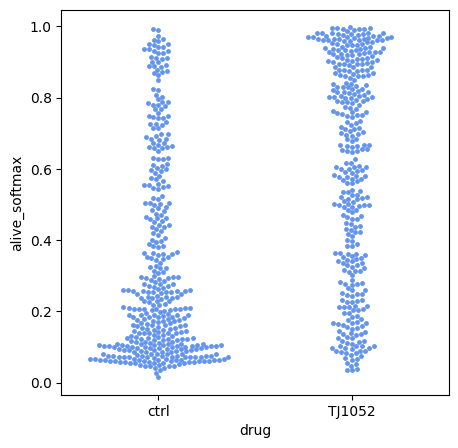

In [ ]:
from shapescore.utils import make_layout_df
import seaborn as sns
res=pd.read_csv('project/'+proj+'/res/res.csv',index_col=['well','plate'])
layout=make_layout_df('project/'+proj)
res['drug']=layout.loc[res.index]['drug']

plt.figure(figsize=(5, 5))
sns.swarmplot(data=res,x='drug',y='alive_softmax', 
              color='cornflowerblue', size=3.5, order=['ctrl','TJ1052'])
plt.show()


Compare well average scores of wild-type (N2) worms veruss age-1 mutants (TJ1052) after 11 hour heat shock

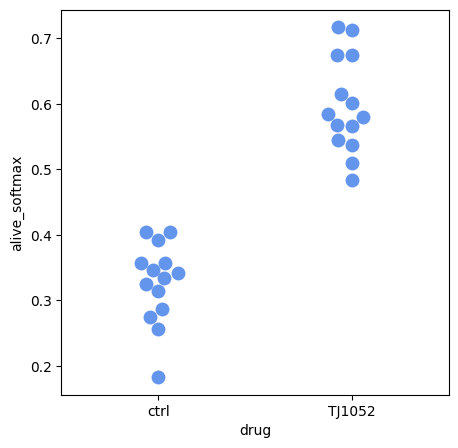

In [ ]:
res_well=res.reset_index()[['alive_softmax','drug', 'well']].groupby(['drug','well']).mean().reset_index()

plt.figure(figsize=(5, 5))
sns.swarmplot(data=res_well,x='drug',y='alive_softmax', 
              color='cornflowerblue', size=10, order=['ctrl','TJ1052'])
plt.ylabel('SAP score')
plt.show()